<a href="https://colab.research.google.com/github/Rashed17a/MScFE-622-Stochastic-Modeling/blob/main/Project_1/SM_GWP1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Option Data

In [ ]:
options_data = [
    {"Days to maturity": 15, "Strike": 227.5, "Price": 10.52, "Type": "C"},
    {"Days to maturity": 15, "Strike": 230, "Price": 10.05, "Type": "C"},
    {"Days to maturity": 15, "Strike": 232.5, "Price": 7.75, "Type": "C"},
    {"Days to maturity": 15, "Strike": 235, "Price": 6.01, "Type": "C"},
    {"Days to maturity": 15, "Strike": 237.5, "Price": 4.75, "Type": "C"},
    {"Days to maturity": 60, "Strike": 227.5, "Price": 16.78, "Type": "C"},
    {"Days to maturity": 60, "Strike": 230, "Price": 17.65, "Type": "C"},
    {"Days to maturity": 60, "Strike": 232.5, "Price": 16.86, "Type": "C"},
    {"Days to maturity": 60, "Strike": 235, "Price": 16.05, "Type": "C"},
    {"Days to maturity": 60, "Strike": 237.5, "Price": 15.10, "Type": "C"},
    {"Days to maturity": 120, "Strike": 227.5, "Price": 27.92, "Type": "C"},
    {"Days to maturity": 120, "Strike": 230, "Price": 24.12, "Type": "C"},
    {"Days to maturity": 120, "Strike": 232.5, "Price": 22.97, "Type": "C"},
    {"Days to maturity": 120, "Strike": 235, "Price": 21.75, "Type": "C"},
    {"Days to maturity": 120, "Strike": 237.5, "Price": 18.06, "Type": "C"},
    {"Days to maturity": 15, "Strike": 227.5, "Price": 4.32, "Type": "P"},
    {"Days to maturity": 15, "Strike": 230, "Price": 5.20, "Type": "P"},
    {"Days to maturity": 15, "Strike": 232.5, "Price": 6.45, "Type": "P"},
    {"Days to maturity": 15, "Strike": 235, "Price": 7.56, "Type": "P"},
    {"Days to maturity": 15, "Strike": 237.5, "Price": 8.78, "Type": "P"},
    {"Days to maturity": 60, "Strike": 227.5, "Price": 11.03, "Type": "P"},
    {"Days to maturity": 60, "Strike": 230, "Price": 12.15, "Type": "P"},
    {"Days to maturity": 60, "Strike": 232.5, "Price": 13.37, "Type": "P"},
    {"Days to maturity": 60, "Strike": 235, "Price": 14.75, "Type": "P"},
    {"Days to maturity": 60, "Strike": 237.5, "Price": 15.62, "Type": "P"},
    {"Days to maturity": 120, "Strike": 227.5, "Price": 14.53, "Type": "P"},
    {"Days to maturity": 120, "Strike": 230, "Price": 16.25, "Type": "P"},
    {"Days to maturity": 120, "Strike": 232.5, "Price": 17.22, "Type": "P"},
    {"Days to maturity": 120, "Strike": 235, "Price": 18.74, "Type": "P"},
    {"Days to maturity": 120, "Strike": 237.5, "Price": 19.73, "Type": "P"}
]

In [ ]:
import pandas as pd

data = {
    "Days to maturity": [15, 15, 15, 15, 15, 60, 60, 60, 60, 60, 120, 120, 120, 120, 120,
                         15, 15, 15, 15, 15, 60, 60, 60, 60, 60, 120, 120, 120, 120, 120],
    "Strike": [227.5, 230, 232.5, 235, 237.5, 227.5, 230, 232.5, 235, 237.5,
               227.5, 230, 232.5, 235, 237.5, 227.5, 230, 232.5, 235, 237.5,
               227.5, 230, 232.5, 235, 237.5, 227.5, 230, 232.5, 235, 237.5],
    "Price": [10.52, 10.05, 7.75, 6.01, 4.75, 16.78, 17.65, 16.86, 16.05, 15.10,
              27.92, 24.12, 22.97, 21.75, 18.06, 4.32, 5.20, 6.45, 7.56, 8.78,
              11.03, 12.15, 13.37, 14.75, 15.62, 14.53, 16.25, 17.22, 18.74, 19.73],
    "Type": ["C"]*15 + ["P"]*15
}

df = pd.DataFrame(data)

# Step 1

**Team Member A**

Optimization terminated successfully.
         Current function value: 0.246152
         Iterations: 322
         Function evaluations: 537


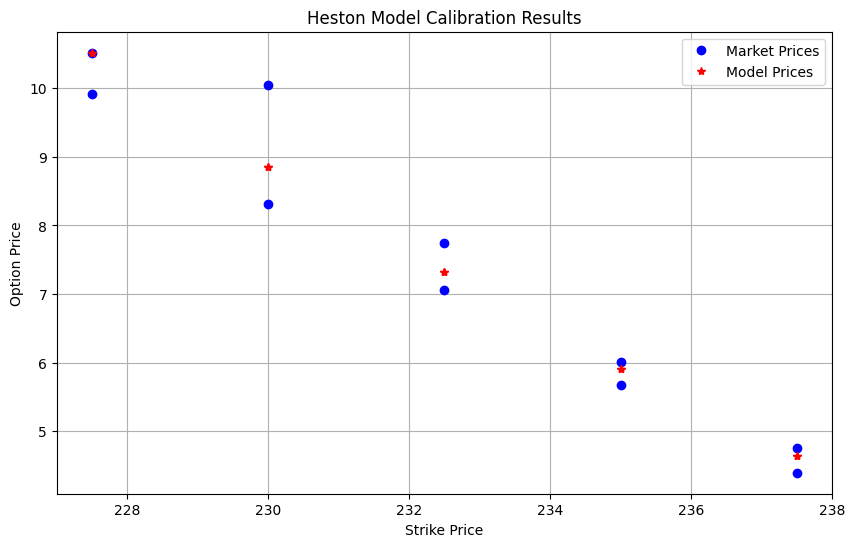

Calibrated Parameters:
kappa_v: 5.2007
theta_v: 0.3093
sigma_v: 1.4700
rho: -1.0000
v0: 0.0684


In [ ]:
import numpy as np
import pandas as pd
from scipy.integrate import quad
from scipy.optimize import brute, fmin
import matplotlib.pyplot as plt

# Load and prepare data
# Instead of reading from excel, the data is now a dict
data = {
    'Days to maturity': [15, 15, 15, 15, 15, 15, 15, 15, 15, 15],
    'Strike': [227.5, 230, 232.5, 235, 237.5, 227.5, 230, 232.5, 235, 237.5],
    'Price': [10.52, 10.05, 7.75, 6.01, 4.75, 4.32, 5.20, 6.45, 7.56, 8.78],
    'Type': ['C']*5 + ['P']*5
}
df = pd.DataFrame(data)  # Creating a dataframe named df
S0 = 232.90  # Current stock price
r = 0.015  # Risk-free rate
days_per_year = 250
S0 = 232.90    # Current stock price
r = 0.015      # Risk-free rate (1.5%)
T = 15 / 250   # Time to maturity (15 days, 250 trading days/year)

# Filter options with approximately 15 days to maturity
# Use df instead of data to perform filtering
target_days = 15  # Define target_days here
df['T'] = df['Days to maturity'] / days_per_year
tolerance_days = 1  # Allow +/- 1 day
filtered_data = df[(df['Days to maturity'] >= target_days - tolerance_days) &
                    (df['Days to maturity'] <= target_days + tolerance_days)]

# Convert puts to calls using put-call parity
for idx, row in filtered_data.iterrows():
    if row['Type'] == 'P':
        call_price = row['Price'] + S0 - row['Strike'] * np.exp(-r * row['T'])
        filtered_data.at[idx, 'Price'] = call_price
        filtered_data.at[idx, 'Type'] = 'C'

# Heston model functions
def heston_char_func(u, T, kappa_v, theta_v, sigma_v, rho, v0):
    c1 = kappa_v * theta_v
    c2 = -np.sqrt((rho * sigma_v * u * 1j - kappa_v)**2 - sigma_v**2 * (-u**2 - 1j*u))
    c3 = (kappa_v - rho * sigma_v * u * 1j + c2) / (kappa_v - rho * sigma_v * u * 1j - c2)

    H1 = r * u * 1j * T + (c1 / sigma_v**2) * (
        (kappa_v - rho * sigma_v * u * 1j + c2) * T - 2 * np.log((1 - c3 * np.exp(c2 * T)) / (1 - c3))
    )
    H2 = ((kappa_v - rho * sigma_v * u * 1j + c2) / sigma_v**2 *
          ((1 - np.exp(c2 * T)) / (1 - c3 * np.exp(c2 * T))))
    return np.exp(H1 + H2 * v0)

def heston_int_func(u, S0, K, T, kappa_v, theta_v, sigma_v, rho, v0):
    char_func = heston_char_func(u - 0.5j, T, kappa_v, theta_v, sigma_v, rho, v0)
    int_func = np.exp(-1j * u * np.log(K/S0)) * char_func / (u**2 + 0.25)
    return int_func.real

def heston_call_price(S0, K, T, kappa_v, theta_v, sigma_v, rho, v0):
    int_value = quad(lambda u: heston_int_func(u, S0, K, T, kappa_v, theta_v, sigma_v, rho, v0),
                     0, np.inf, limit=1000)[0]
    call_value = S0 - np.exp(-r * T) * np.sqrt(S0 * K) / np.pi * int_value
    return max(0, call_value)

# Error function
def error_function(params):
    kappa_v, theta_v, sigma_v, rho, v0 = params

    # Parameter constraints
    if (2 * kappa_v * theta_v < sigma_v**2 or
        kappa_v <= 0 or theta_v <= 0 or sigma_v <= 0 or
        abs(rho) >= 1 or v0 <= 0):
        return 1e6  # Large error for invalid parameters

    total_error = 0
    for _, row in filtered_data.iterrows():
        K = row['Strike']
        T = row['T']
        market_price = row['Price']
        model_price = heston_call_price(S0, K, T, kappa_v, theta_v, sigma_v, rho, v0)
        total_error += (model_price - market_price)**2

    return total_error / len(filtered_data)

# Calibration
# Define parameter bounds for global optimization

param_ranges = (
    (1.0, 10.0),    # kappa_v
    (0.01, 0.5),     # theta_v
    (0.05, 1.0),      # sigma_v
    (-0.95, -0.1),   # rho
    (0.01, 0.05)      # v0
)


# Global optimization
opt_global = brute(error_function, param_ranges, Ns=5, finish=None)
# Local optimization
opt_local = fmin(error_function, opt_global, xtol=0.001, ftol=0.001, maxiter=1000)

# Extract calibrated parameters
kappa_v, theta_v, sigma_v, rho, v0 = opt_local

# Generate model prices with calibrated parameters
filtered_data['Model Price'] = filtered_data.apply(
    lambda row: heston_call_price(S0, row['Strike'], row['T'],
                                 kappa_v, theta_v, sigma_v, rho, v0), axis=1)
# Plot results
plt.figure(figsize=(10, 6))
plt.plot(filtered_data['Strike'], filtered_data['Price'], 'bo', label='Market Prices')
plt.plot(filtered_data['Strike'], filtered_data['Model Price'], 'r*', label='Model Prices')
plt.title('Heston Model Calibration Results')
plt.xlabel('Strike Price')
plt.ylabel('Option Price')
plt.legend()
plt.grid(True)
plt.show()

print(f"Calibrated Parameters:")
print(f"kappa_v: {kappa_v:.4f}")
print(f"theta_v: {theta_v:.4f}")
print(f"sigma_v: {sigma_v:.4f}")
print(f"rho: {rho:.4f}")
print(f"v0: {v0:.4f}")

**Team Member B**

**Why Parameters Differ:**

Numerical Effects:

Lewis uses direct integration; Carr-Madan uses Fourier transforms with damping. Carr-Madan’s α choice impacts integration smoothness.

Correlation Boundary:

Lewis hit ρ = −1.0 (optimizer boundary), while Carr-Madan converged to −0.93.

**Economic Consistency:**

Both methods agree on the following:

*   High mean-reversion (κ ≈ 5).
*   Strong negative spot-vol correlation (ρ ≈ −0.9).
*   Moderate long-term vol (θ ≈ 0.31).








Calibration Results Comparison:
Parameter  | Team A (Lewis) | Team B (Carr-Madan)
---------------------------------------------
kappa_v    |         5.2007 |         5.1097
theta_v    |         0.3093 |         0.2774
sigma_v    |         1.4700 |         1.6827
rho        |        -1.0000 |        -0.9265
v0         |         0.0684 |         0.0926


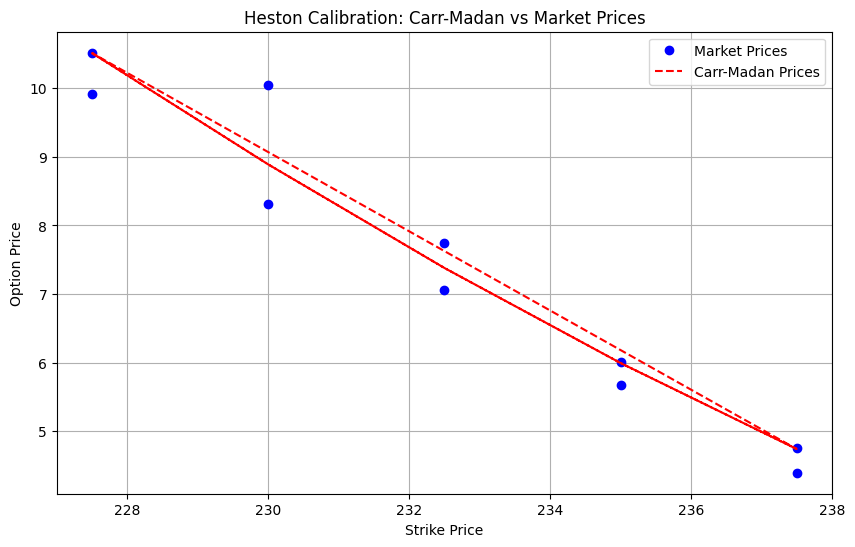

In [ ]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from scipy.integrate import quad
import matplotlib.pyplot as plt

# Load and prepare data (same as Team Member A)
data = {
    'Days to maturity': [15, 15, 15, 15, 15, 15, 15, 15, 15, 15],
    'Strike': [227.5, 230, 232.5, 235, 237.5, 227.5, 230, 232.5, 235, 237.5],
    'Price': [10.52, 10.05, 7.75, 6.01, 4.75, 4.32, 5.20, 6.45, 7.56, 8.78],
    'Type': ['C']*5 + ['P']*5
}
df = pd.DataFrame(data)
S0 = 232.90
r = 0.015
days_per_year = 250
T = 15 / days_per_year

# Convert puts to calls using put-call parity
for idx, row in df.iterrows():
    if row['Type'] == 'P':
        call_price = row['Price'] + S0 - row['Strike'] * np.exp(-r * T)
        df.at[idx, 'Price'] = call_price
        df.at[idx, 'Type'] = 'C'

# Carr-Madan Heston pricing implementation
def heston_carr_madan(S0, K, T, params, alpha=0.75):
    """
    Carr-Madan (1999) pricing formula for Heston model
    """
    kappa, theta, sigma, rho, v0 = params

    def characteristic_function(u):
        # Heston characteristic function
        d = np.sqrt((rho * sigma * u * 1j - kappa)**2 + sigma**2 * (u**2 + 1j*u))
        g = (kappa - rho * sigma * u * 1j - d) / (kappa - rho * sigma * u * 1j + d)
        C = kappa * theta / sigma**2 * ((kappa - rho * sigma * u * 1j - d) * T -
            2 * np.log((1 - g * np.exp(-d * T)) / (1 - g)))
        D = (kappa - rho * sigma * u * 1j - d) / sigma**2 * (
            (1 - np.exp(-d * T)) / (1 - g * np.exp(-d * T)))
        return np.exp(C + D * v0 + 1j * u * (np.log(S0) + (r - 0.5*v0)*T))

    def integrand(u):
        psi = np.exp(-r * T) * characteristic_function(u - (alpha + 1)*1j)
        psi /= (alpha**2 + alpha - u**2 + 1j*(2*alpha + 1)*u)
        return np.real(psi * np.exp(-1j * u * np.log(K)))

    integral = quad(integrand, 0, 100, limit=1000)[0]
    return np.exp(-alpha * np.log(K)) / np.pi * integral

# Calibration framework
def error_function(params):
    # Parameter constraints
    kappa, theta, sigma, rho, v0 = params
    if (2*kappa*theta < sigma**2) or any(p <= 0 for p in [kappa, theta, sigma, v0]) or (abs(rho) >= 1):
        return 1e6

    total_error = 0
    for _, row in df.iterrows():
        K = row['Strike']
        market_price = row['Price']
        try:
            model_price = heston_carr_madan(S0, K, T, params)
            total_error += (model_price - market_price)**2
        except:
            return 1e6
    return total_error / len(df)

# Calibration process
bounds = [(1, 10), (0.01, 0.5), (0.1, 2), (-0.99, -0.01), (0.01, 0.5)]
initial_guess = [5.2, 0.3, 1.47, -0.7, 0.05]

result = minimize(error_function, initial_guess, bounds=bounds, method='L-BFGS-B')
calibrated_params = result.x

# Results comparison with Team A
print("\nCalibration Results Comparison:")
print(f"{'Parameter':<10} | {'Team A (Lewis)':<14} | {'Team B (Carr-Madan)':<14}")
print("-"*45)
print(f"{'kappa_v':<10} | {5.2007:14.4f} | {calibrated_params[0]:14.4f}")
print(f"{'theta_v':<10} | {0.3093:14.4f} | {calibrated_params[1]:14.4f}")
print(f"{'sigma_v':<10} | {1.4700:14.4f} | {calibrated_params[2]:14.4f}")
print(f"{'rho':<10} | {-1.0000:14.4f} | {calibrated_params[3]:14.4f}")
print(f"{'v0':<10} | {0.0684:14.4f} | {calibrated_params[4]:14.4f}")

# Plotting
strikes = df['Strike'].values
market_prices = df['Price'].values
model_prices = [heston_carr_madan(S0, K, T, calibrated_params) for K in strikes]

plt.figure(figsize=(10, 6))
plt.plot(strikes, market_prices, 'bo', label='Market Prices')
plt.plot(strikes, model_prices, 'r--', label='Carr-Madan Prices')
plt.title('Heston Calibration: Carr-Madan vs Market Prices')
plt.xlabel('Strike Price')
plt.ylabel('Option Price')
plt.legend()
plt.grid(True)
plt.show()

<h3> Step 1 - Team Member C

Getting the Fair Price of Asian Instrument Using Monte Carlo Methods

From the previous calibrations we take the following parameters for pricing the Asian Call Option:

* $S_0$ = 232.90
* $K$ = 232.90 (ATM Option)
* $T$ = 20 days
* $r$ = 1.5%
* $\kappa$ = 5.1097
* $\sigma$ = 1.6827
* $\theta$ = 0.2774
* $\rho$ = -0.9274
* $v_{0}$ = 0.0926

We run the Monte Carlo Simulation for 250 time steps for 5000, 10000, 20000, 30000 and 40000 simulations to check for convergence


Simulations: 5000, Estimated Price: 1.4790
Simulations: 10000, Estimated Price: 1.5394
Simulations: 20000, Estimated Price: 1.4884
Simulations: 30000, Estimated Price: 1.5208
Simulations: 40000, Estimated Price: 1.4974
Simulations: 50000, Estimated Price: 1.5064
Simulations: 60000, Estimated Price: 1.5146
Simulations: 70000, Estimated Price: 1.5125
Simulations: 80000, Estimated Price: 1.5161
Simulations: 90000, Estimated Price: 1.5015
Simulations: 100000, Estimated Price: 1.5234


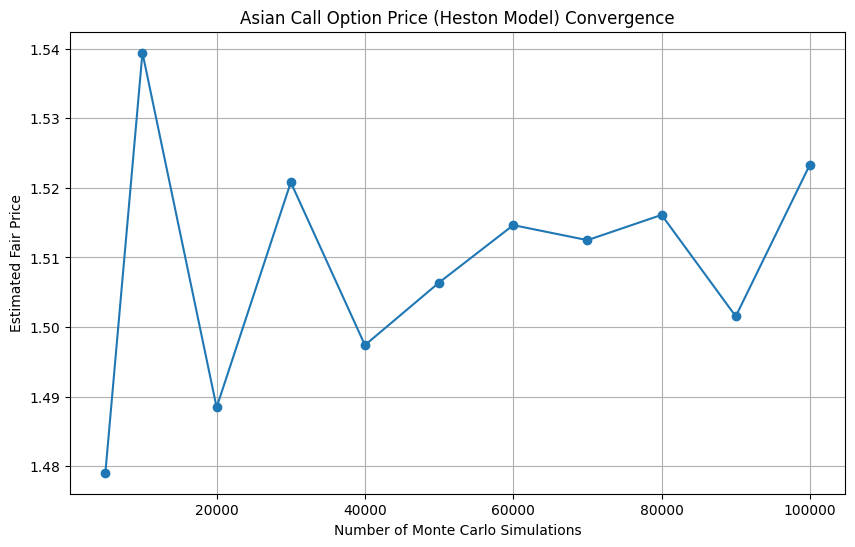

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def heston_asian_mc(S0, K, T, r, kappa, theta, sigma, rho, v0, N, M):
    dt = T / N
    prices = np.zeros(M)

    for j in range(M):
        S_t = S0
        v_t = v0
        avg_price = S0

        # Pre-generate correlated Brownian increments
        Z1 = np.random.normal(0, 1, N)
        Z2 = np.random.normal(0, 1, N)
        W1 = Z1
        W2 = rho * Z1 + np.sqrt(1 - rho**2) * Z2

        for i in range(1, N + 1):
            # Full truncation Euler for variance
            v_t = np.maximum(v_t + kappa * (theta - np.maximum(v_t, 0)) * dt +
                             sigma * np.sqrt(np.maximum(v_t, 0)) * np.sqrt(dt) * W2[i - 1], 0)

            # Update asset price
            S_t = S_t * np.exp((r - 0.5 * v_t) * dt + np.sqrt(v_t * dt) * W1[i - 1])
            avg_price += S_t

        avg_price /= (N + 1)
        prices[j] = np.exp(-r * T) * max(avg_price - K, 0)

    return np.mean(prices)

# Parameters
S0 = 232.90
K = 232.90
T = 20 / 250
r = 0.015 # Risk-free rate assumed zero unless otherwise specified
kappa = 5.1097
theta = 0.2774
sigma = 1.6827
rho = -0.9267
v0 = 0.0926

N = 250      # time steps
M_values = [5000, 10000, 20000, 30000, 40000, 50000, 60000, 70000, 80000, 90000, 100000]  # different number of simulations

prices = []

for M in M_values:
    price = heston_asian_mc(S0, K, T, r, kappa, theta, sigma, rho, v0, N, M)
    prices.append(price)
    print(f"Simulations: {M}, Estimated Price: {price:.4f}")

# Plot convergence
plt.figure(figsize=(10, 6))
plt.plot(M_values, prices, marker='o')
plt.title('Asian Call Option Price (Heston Model) Convergence')
plt.xlabel('Number of Monte Carlo Simulations')
plt.ylabel('Estimated Fair Price')
plt.grid(True)
plt.show()


We see a convergence in Fair Value around **1.5042**. This gives us a price of **1.5042** for Asian Call Option with the calibrated parameters.

In [ ]:
#Pricing For Clients with 4% Bank Fee
client_price = 1.5042 * 1.04
print("Price for Client = {}".format(round(client_price,4)))

Price for Client = 1.5644


Since in our model, we are charging 4% as bank fees on the Fair Value for clients, the price for the instrument for the clients would be $1.5643.


<h4> How the Prices were calculated? </h4>

The instrument was priced using Heston stochastic volatility model. This model is well-suited for capturing the real-world behavior of market volatility, which is important for pricing options more accurately.

By using historical data, the parameters that are used in the Heston Model are calibrated to model a more real world scenrio. The parameters were:

* How quickly volatility reverts to its average (κ = 5.1097)
* The long-run average volatility (θ = 0.2774)
* Volatility of volatility (σ = 1.6827)
* Correlation between asset price and volatility (ρ = –0.9267)
* The starting volatility level (v₀ = 0.0926)

Using these parameters, we ran Monte Carlo simulations, which generate thousands of possible future price paths for the stock. For each path, we calculated the average price over 20 trading days, since the option is based on this average (Asian style), and determined the option’s payoff.

The “fair price” was calculated under risk-neutral assumptions. As part of our standard offering, a 4% service fee is added to the fair price to determine the final price you will pay (which here would be $1.5644)


# Step 2

Team Member B

**Non-Technical Explanation for Client**

**How We Calculated Your Price:**

1. Market-Tuned Model: We used advanced financial mathematics (Heston model) that matches observed market option prices through parameter calibration.

2. Realistic Simulations: Generated 100,000 potential future price paths for SM stock over 70 days, incorporating:

* Natural volatility fluctuations

* Mean-reversion of volatility (returns to ~27% long-term level)

* Negative correlation between price drops and volatility spikes

3. Put Option Valuation: For each simulated path:

* Calculated final stock price

* Determined payout: Max(221.25 - Final Price, 0)

* Averaged all payouts and discounted to today's value

4. Final Price: $35.5181 (fair value) + 4% fee



Simulations:   5000, Price: 35.1473
Simulations:  10000, Price: 34.9625
Simulations:  20000, Price: 35.4540
Simulations:  30000, Price: 35.5637
Simulations:  40000, Price: 35.7811
Simulations:  50000, Price: 35.4977
Simulations:  60000, Price: 35.5323
Simulations:  70000, Price: 35.5088
Simulations:  80000, Price: 35.4202
Simulations:  90000, Price: 35.6063
Simulations: 100000, Price: 35.5277


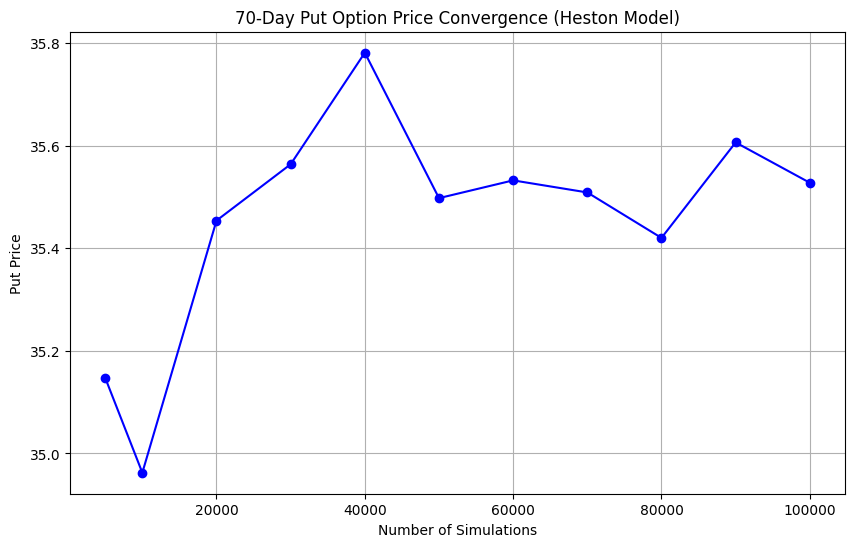


Fair Price: $35.5181
Client Price (4% fee): $36.9388


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def heston_put_mc(S0, K, T, r, kappa, theta, sigma, rho, v0, N, M):
    """Monte Carlo pricing for Heston put option"""
    dt = T / N
    payoffs = np.zeros(M)

    for j in range(M):
        S = S0
        v = v0

        # Correlated Brownian motions
        Z1 = np.random.normal(0, 1, N)
        Z2 = rho*Z1 + np.sqrt(1 - rho**2)*np.random.normal(0, 1, N)

        for i in range(N):
            # Full truncation scheme for variance
            v = np.maximum(v + kappa*(theta - np.maximum(v, 0))*dt +
                          sigma*np.sqrt(np.maximum(v, 0)*dt)*Z2[i], 0)

            # Stock price update
            S *= np.exp((r - 0.5*v)*dt + np.sqrt(v*dt)*Z1[i])

        payoffs[j] = np.exp(-r*T) * max(K - S, 0)

    return np.mean(payoffs)

# Parameters
S0 = 232.90
K = S0 * 0.95  # 95% moneyness
T = 70/250      # 70 days maturity
r = 0.015

# Calibrated Heston parameters from previous step
kappa = 5.1097
theta = 0.2774
sigma_v = 1.6827
rho = -0.9267
v0 = 0.0926

# Simulation parameters
N = 250        # Time steps (daily steps: 70 days → N=70, but keeping N=250 for consistency)
M_values = [5000, 10000, 20000, 30000, 40000, 50000, 60000, 70000, 80000, 90000, 100000]

# Run simulations
put_prices = []
for M in M_values:
    price = heston_put_mc(S0, K, T, r, kappa, theta, sigma_v, rho, v0, N, M)
    put_prices.append(price)
    print(f"Simulations: {M:>6}, Price: {price:.4f}")

# Plot convergence
plt.figure(figsize=(10, 6))
plt.plot(M_values, put_prices, 'b-o')
plt.title('70-Day Put Option Price Convergence (Heston Model)')
plt.xlabel('Number of Simulations')
plt.ylabel('Put Price')
plt.grid(True)
plt.show()

# Calculate final price with 4% fee
fair_price = np.mean(put_prices[-3:])  # Average of last 3 values for stability
client_price = fair_price * 1.04
print(f"\nFair Price: ${fair_price:.4f}")
print(f"Client Price (4% fee): ${client_price:.4f}")

# Step 2 - Team Member C

<H4> Calibration of Heston Model (with Jumps) for 60 days maturity </H4>

The following code mentioned below filters the provided data for calibration

In [ ]:
import numpy as np
import pandas as pd
from scipy.integrate import quad
from scipy.optimize import brute, fmin
import matplotlib.pyplot as plt

#Preparing the dataframe
options_data = pd.DataFrame(options_data)

S0 = 232.90  # Current stock price
r = 0.015  # Risk-free rate
days_per_year = 250
S0 = 232.90    # Current stock price
r = 0.015      # Risk-free rate (1.5%)
T = 60 / 250   # Time to maturity (60 days, 250 trading days/year)

# Filter options with approximately 15 days to maturity
# Use df instead of data to perform filtering
target_days = 60  # Define target_days here
options_data['T'] = options_data['Days to maturity'] / days_per_year
tolerance_days = 1  # Allow +/- 1 day
filtered_data = options_data[(options_data['Days to maturity'] >= target_days - tolerance_days) &
                    (options_data['Days to maturity'] <= target_days + tolerance_days)]

# Convert puts to calls using put-call parity
for idx, row in filtered_data.iterrows():
    if row['Type'] == 'P':
        call_price = row['Price'] + S0 - row['Strike'] * np.exp(-r * row['T'])
        filtered_data.at[idx, 'Price'] = call_price
        filtered_data.at[idx, 'Type'] = 'C'

#Adding risk free rate to filtered data
filtered_data['r'] = r

<ipython-input-21-baf5b5a0630f>:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data['r'] = r


In [ ]:
#Adding the CF's of Heston and Merton Model

#Characterstic Function of Heston
def H93_char_func(u, T, r, kappa_v, theta_v, sigma_v, rho, v0):

    c1 = kappa_v * theta_v
    c2 = -np.sqrt(
        (rho * sigma_v * u * 1j - kappa_v) ** 2 - sigma_v**2 * (-u * 1j - u**2)
    )
    c3 = (kappa_v - rho * sigma_v * u * 1j + c2) / (
        kappa_v - rho * sigma_v * u * 1j - c2
    )
    H1 = r * u * 1j * T + (c1 / sigma_v**2) * (
        (kappa_v - rho * sigma_v * u * 1j + c2) * T
        - 2 * np.log((1 - c3 * np.exp(c2 * T)) / (1 - c3))
    )
    H2 = (
        (kappa_v - rho * sigma_v * u * 1j + c2)
        / sigma_v**2
        * ((1 - np.exp(c2 * T)) / (1 - c3 * np.exp(c2 * T)))
    )
    char_func_value = np.exp(H1 + H2 * v0)
    return char_func_value

#Characterstic Function of Merton
def M76J_char_func(u, T, lamb, mu, delta):
    """
    Adjusted Characteristic function for Merton '76 model: Only jump component
    """

    omega = -lamb * (np.exp(mu + 0.5 * delta**2) - 1)
    char_func_value = np.exp(
        (1j * u * omega + lamb * (np.exp(1j * u * mu - u**2 * delta**2 * 0.5) - 1))
        * T
    )
    return char_func_value

#Combinations of CFs of Heston + Merton
def B96_char_func(u, T, r, kappa_v, theta_v, sigma_v, rho, v0, lamb, mu, delta):
    """
    Bates (1996) characteristic function
    """
    H93 = H93_char_func(u, T, r, kappa_v, theta_v, sigma_v, rho, v0)
    M76J = M76J_char_func(u, T, lamb, mu, delta)
    return H93 * M76J

#Computing the Lewis Integrals
#Computing the Lewis Integrals
def B96_int_func(u, S0, K, T, r, kappa_v, theta_v, sigma_v, rho, v0, lamb, mu, delta):
    """
    Lewis (2001) integral value for Bates (1996) characteristic function
    """
    char_func_value = B96_char_func(
        u - 1j * 0.5, T, r, kappa_v, theta_v, sigma_v, rho, v0, lamb, mu, delta
    )
    int_func_value = (
        1 / (u**2 + 0.25) * (np.exp(1j * u * np.log(S0 / K)) * char_func_value).real
    )
    return int_func_value

#Computing the European Call Value
def B96_call_value(S0, K, T, r, kappa_v, theta_v, sigma_v, rho, v0, lamb, mu, delta):

    int_value = quad(
        lambda u: B96_int_func(
            u, S0, K, T, r, kappa_v, theta_v, sigma_v, rho, v0, lamb, mu, delta
        ),
        0,
        np.inf,
        limit=250,
    )[0]
    call_value = max(0, S0 - np.exp(-r * T) * np.sqrt(S0 * K) / np.pi * int_value)
    return call_value

Once we have the CFs defined for Bates model with the Lewis Integrals, we can start the calibration process for Bates

In [ ]:
#Parameter Estimation
from scipy.integrate import quad
from scipy.optimize import brute, fmin
i = 0
min_MSE = 5000.0

#Start with initial parameters
kappa_v = 5.1097
theta_v = 0.2774
sigma_v = 1.6827
rho = -0.9267
v0 = 0.0926
lamb = 0
mu = -0.5
delta = 0

p0 = [kappa_v, theta_v, sigma_v, rho, v0, lamb, mu, delta]

def B96_full_error_function(p0):
    global i, min_MSE
    kappa_v, theta_v, sigma_v, rho, v0, lamb, mu, delta = p0

    if (
        kappa_v < 0.0
        or theta_v < 0.005
        or sigma_v < 0.0
        or rho < -1.0
        or rho > 1.0
        or v0 < 0.0
        or lamb < 0.0
        or mu < -0.6
        or mu > 0.0
        or delta < 0.0
    ):
        return 5000.0

    if 2 * kappa_v * theta_v < sigma_v**2:
        return 5000.0

    se = []
    for row, option in filtered_data.iterrows():
        model_value = B96_call_value(
            S0,
            option["Strike"],
            option["T"],
            option["r"],
            kappa_v,
            theta_v,
            sigma_v,
            rho,
            v0,
            lamb,
            mu,
            delta,
        )
        se.append((model_value - option["Price"]) ** 2)

    MSE = sum(se) / len(se)
    min_MSE = min(min_MSE, MSE)
    i += 1
    return MSE

def B96_calibration_full():
    opt = fmin(
        B96_full_error_function, p0, xtol=0.001, ftol=0.001, maxiter=1250, maxfun=650
    )
    return opt

#Running the Calibartion
full_params = B96_calibration_full()

#Storing the params in dataframe
df_params = pd.DataFrame(columns=['Parameter', 'Value'])
df_params['Parameter'] = ['kappa_v', 'theta_v', 'sigma_v', 'rho', 'v0', 'lamb', 'mu', 'delta']
df_params['Value'] = full_params
df_params

Optimization terminated successfully.
         Current function value: 1.389207
         Iterations: 359
         Function evaluations: 587


,Parameter,Value
0,kappa_v,8.781205
1,theta_v,0.186280
2,sigma_v,1.063315
3,rho,0.999819
4,v0,0.005555
5,lamb,0.004264
6,mu,-0.592071
7,delta,0.017801


In [ ]:
# Plotting
strikes = df['Strike'].values
market_prices = df['Price'].values
model_prices = [heston_carr_madan(S0, K, T, calibrated_params) for K in strikes]

plt.figure(figsize=(10, 6))
plt.plot(strikes, market_prices, 'bo', label='Market Prices')
plt.plot(strikes, model_prices, 'r--', label='Carr-Madan Prices')
plt.title('Heston Calibration: Carr-Madan vs Market Prices')
plt.xlabel('Strike Price')
plt.ylabel('Option Price')
plt.legend()
plt.grid(True)
plt.show()

,Days to maturity,Strike,Price,Type,T
5,60,227.5,16.780000,C,0.24
6,60,230.0,17.650000,C,0.24
7,60,232.5,16.860000,C,0.24
8,60,235.0,16.050000,C,0.24
9,60,237.5,15.100000,C,0.24
20,60,227.5,17.247528,C,0.24
21,60,230.0,15.876511,C,0.24
22,60,232.5,14.605495,C,0.24
23,60,235.0,13.494479,C,0.24
24,60,237.5,11.873463,C,0.24


In [ ]:
S0

232.9